In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = pd.read_parquet("../data/processed/vuelos_clima_2025q1.parquet")
df["estado"] = df["estado"].astype("category")
normal = df[df["estado"] == "normal"]

print("Forma:", df.shape)
print("\nKPIs globales (35 aeropuertos de origen, ene-mar 2025):")
print(f"  Vuelos totales:        {len(df):,}")
print(f"  % puntualidad (<15 min, vuelos normal): {(normal['ArrDel15'] == 0).mean():.1%}")
print(f"  Retraso medio llegada:   {normal['ArrDelay'].mean():.1f} min | mediana: {normal['ArrDelay'].median():.0f} min")
print(f"  % cancelados:            {(df['estado'] == 'cancelado').mean():.2%}")
print(f"  % desviados:             {(df['estado'] == 'desviado').mean():.2%}")

print("\nTipos conservados tras el parquet:")
print(df.dtypes.value_counts())

Forma: (1138858, 49)

KPIs globales (35 aeropuertos de origen, ene-mar 2025):
  Vuelos totales:        1,138,858
  % puntualidad (<15 min, vuelos normal): 79.8%
  Retraso medio llegada:   4.8 min | mediana: -7 min
  % cancelados:            1.74%
  % desviados:             0.25%

Tipos conservados tras el parquet:
float64           13
Float64            7
Int16              4
Int8               4
int64              3
bool               2
boolean            2
category           2
category           2
category           1
datetime64[ns]     1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
Name: count, dtype: int64


Las 1.138.858 filas y 49 columnas coinciden con el dataset final. El 79,8 % de los vuelos `normal` llega con menos de 15 min de retraso; la media (4,8 min) es mayor que la mediana (-7 min) por la cola de retrasos extremos ya descrita. Las tasas de cancelación (1,74 %) y desvío (0,25 %) también coinciden con el notebook 02. Los tipos se conservan correctamente, salvo `estado`, que quedó como `object` y se reconvierte a `category` a continuación

### 2. Retraso de llegada por aerolínea, franja horaria y día de la semana

Se compara la mediana de `ArrDelay` y el % de puntualidad (< 15 min) entre aerolíneas, franjas horarias y días de la semana, en los vuelos `normal`. Es un análisis descriptivo; la significación estadística se evaluará en el notebook 04.

In [9]:
dias = {1: "Lunes", 2: "Martes", 3: "Miércoles", 4: "Jueves", 5: "Viernes", 6: "Sábado", 7: "Domingo"}
normal = normal.assign(dia_semana=normal["DayOfWeek"].map(dias))

for col in ["Reporting_Airline", "franja_hora", "dia_semana"]:
    resumen = normal.groupby(col, observed=True).agg(
        vuelos=("ArrDelay", "size"),
        mediana_retraso=("ArrDelay", "median"),
        pct_puntual=("ArrDel15", lambda s: (s == 0).mean() * 100)
    ).round(1)
    print(f"--- {col} ---")
    print(resumen.sort_values("mediana_retraso", ascending=False), "\n")

--- Reporting_Airline ---
                   vuelos  mediana_retraso  pct_puntual
Reporting_Airline                                      
HA                   9969             -1.0         83.7
OH                  31803             -2.0         69.8
AS                  37827             -5.0         79.6
MQ                  35762             -6.0         80.3
AA                 179058             -7.0         78.6
B6                  39443             -7.0         74.7
OO                 107576             -7.0         78.2
WN                 212677             -7.0         82.2
F9                  37706             -7.0         74.9
DL                 181181             -8.0         80.1
UA                 145064             -9.0         82.2
NK                  43363             -9.0         81.1
G4                   4211             -9.0         80.0
YX                  50567            -10.0         82.0 

--- franja_hora ---
                  vuelos  mediana_retraso  pct_puntual
f

Por **aerolínea**, la puntualidad va del 69,8 % (OH) al 83,7 % (HA), un rango de 14 puntos, y la mediana de retraso oscila entre -1 y -10 min. No hay una diferencia extrema entre operadores.

Por **franja horaria**, la relación es más marcada y consistente: a medida que avanza el día empeora la puntualidad, de 91,2 % en madrugada a 74,8 % en noche. Es coherente con el efecto de acumulación de retrasos a lo largo de la jornada operativa.

Por **día de la semana**, martes y miércoles son los más puntuales (85,0 % y 83,4 %) y domingo el peor (75,1 %), aunque las diferencias son menores que por franja horaria.

Estas diferencias son descriptivas; su significación se contrastará en el notebook 04 con Kruskal-Wallis (más de dos grupos) y las comparaciones post-hoc correspondientes, dado que `ArrDelay` no sigue una distribución normal

## 3. Relación entre clima y retraso de llegada

Se compara la mediana de `ArrDelay` y el % de puntualidad según la intensidad de la precipitación, del viento y la presencia de clima adverso o nieve aproximada, en el aeropuerto de origen, para los vuelos `normal`.

In [10]:
for col in ["precip_cat", "viento_cat", "clima_adverso", "nieve_aprox"]:
    resumen = normal.groupby(col, observed=True).agg(
        vuelos=("ArrDelay", "size"),
        mediana_retraso=("ArrDelay", "median"),
        pct_puntual=("ArrDel15", lambda s: (s == 0).mean() * 100)
    ).round(1)
    print(f"--- {col} ---")
    print(resumen, "\n")

# Correlación de Spearman entre variables continuas de clima y retraso
clima_cols = ["prcp_orig", "wspd_orig", "tavg_orig"]
corr = normal[clima_cols + ["ArrDelay"]].corr(method="spearman")["ArrDelay"].drop("ArrDelay")
print("Correlación de Spearman con ArrDelay:")
print(corr.round(3))

--- precip_cat ---
            vuelos  mediana_retraso  pct_puntual
precip_cat                                      
Sin lluvia  837623             -8.0         83.1
Ligera      174981             -3.0         71.7
Moderada     63493             -1.0         68.3
Intensa      40110              0.0         65.9 

--- viento_cat ---
            vuelos  mediana_retraso  pct_puntual
viento_cat                                      
Flojo       652247             -8.0         82.2
Moderado    381810             -6.0         77.0
Fuerte       82150             -5.0         73.8 

--- clima_adverso ---
               vuelos  mediana_retraso  pct_puntual
clima_adverso                                      
False          957243             -8.0         81.8
True           158964             -1.0         67.9 

--- nieve_aprox ---
              vuelos  mediana_retraso  pct_puntual
nieve_aprox                                       
False        1072643             -8.0         80.8
True          

La relación es consistente y con gradiente claro en **precipitación**: la puntualidad baja de 83,1 % (sin lluvia) a 65,9 % (intensa), y la mediana pasa de -8 a 0 min. El **viento** muestra el mismo patrón, más suave: de 82,2 % (flojo) a 73,8 % (fuerte).

La variable **clima_adverso** separa bien los dos grupos: 81,8 % de puntualidad sin él frente a 67,9 % con él (14 puntos de diferencia). El efecto más marcado es el de **nieve_aprox**: con nieve la mediana de retraso es positiva (+9 min, frente a -8 min sin ella) y la puntualidad cae a 56,4 %, muy por debajo del resto de categorías.

Las correlaciones de Spearman confirman la dirección pero son débiles en magnitud: 0,137 para precipitación, 0,069 para viento y prácticamente nula para temperatura (-0,005), esperable porque el retraso depende también de la aerolínea, la franja horaria y la propagación de retrasos en la red aérea, no solo del clima puntual de origen.

Estas diferencias descriptivas se contrastarán en el notebook 04 con Mann-Whitney (grupos de dos, como `clima_adverso` y `nieve_aprox`) y Kruskal-Wallis (grupos de más de dos, como `precip_cat` y `viento_cat`), con el tamaño del efecto y la corrección por comparaciones múltiples correspondientes.

## 4. Tasa de cancelación según clima y aerolínea

Se calcula el % de vuelos cancelados por categoría de clima adverso y por aerolínea, ya que las cancelaciones se excluyeron del análisis de `ArrDelay` y no se han caracterizado hasta ahora.

In [11]:
print("Tasa de cancelación por clima adverso:")
print((df.groupby("clima_adverso", observed=True)["estado"]
       .apply(lambda s: (s == "cancelado").mean() * 100)).round(2))

print("\nTasa de cancelación por nieve aproximada:")
print((df.groupby("nieve_aprox", observed=True)["estado"]
       .apply(lambda s: (s == "cancelado").mean() * 100)).round(2))

print("\nTasa de cancelación por aerolínea (top 5 y bottom 5):")
tasa_aerolinea = (df.groupby("Reporting_Airline", observed=True)["estado"]
                  .apply(lambda s: (s == "cancelado").mean() * 100)).round(2).sort_values(ascending=False)
print(tasa_aerolinea.head(5))
print(tasa_aerolinea.tail(5))

Tasa de cancelación por clima adverso:
clima_adverso
False    1.19
True     4.93
Name: estado, dtype: float64

Tasa de cancelación por nieve aproximada:
nieve_aprox
False    1.56
True     6.01
Name: estado, dtype: float64

Tasa de cancelación por aerolínea (top 5 y bottom 5):
Reporting_Airline
OH    7.57
MQ    3.02
YX    2.94
AA    2.14
F9    1.86
Name: estado, dtype: float64
Reporting_Airline
HA    1.29
AS    1.20
DL    1.06
UA    0.83
G4    0.75
Name: estado, dtype: float64


Con clima adverso, la tasa de cancelación es del 4,93 %, frente al 1,19 % sin él, más de 4 veces superior. Con nieve aproximada el contraste es aún mayor: 6,01 % frente a 1,56 %. Por aerolínea, la tasa oscila entre 0,75 % (G4) y 7,57 % (OH), una diferencia notable que no se ha cruzado con el clima ni con el tipo de aeropuerto que opera cada aerolínea.

Con esto se completa el análisis descriptivo: retraso y cancelación caracterizados frente a clima, aerolínea, franja horaria y día de la semana. La significación de estas diferencias se contrastará en el notebook 04, donde la cancelación (variable binaria) se analizará con chi-cuadrado, distinto de los tests para `ArrDelay` (variable continua).

## 5. Resumen del análisis descriptivo

- **Volumen:** 1.138.858 vuelos con origen en los 35 aeropuertos con más tráfico (69,2 % del total del BTS, ene-mar 2025).
- **Puntualidad global:** 79,8 % de los vuelos `normal` llega con menos de 15 min de retraso (mediana de -7 min).
- **Aerolínea:** diferencia moderada, de 69,8 % a 83,7 % de puntualidad según operador.
- **Franja horaria:** efecto claro y creciente a lo largo del día, de 91,2 % (madrugada) a 74,8 % (noche).
- **Día de la semana:** diferencia menor, con martes y miércoles más puntuales que domingo.
- **Clima:** relación consistente con gradiente en precipitación y viento; el clima adverso reduce la puntualidad de 81,8 % a 67,9 %, y la nieve aproximada de 80,8 % a 56,4 %.
- **Cancelaciones:** el clima adverso multiplica por 4 la tasa de cancelación (4,93 % frente a 1,19 %); la nieve por casi 4 (6,01 % frente a 1,56 %). Por aerolínea varía de 0,75 % a 7,57 %.

**Siguiente paso.** Estas diferencias son descriptivas. El notebook `04_estadistica.ipynb` evalúa su significación (Kruskal-Wallis, Mann-Whitney, chi-cuadrado, Spearman), con tamaño del efecto y corrección por comparaciones múltiples.

## 6. Visualizaciones

Se generan las figuras que ilustran los hallazgos principales del análisis descriptivo, guardadas en `reports/figures/` para el informe y el dashboard.

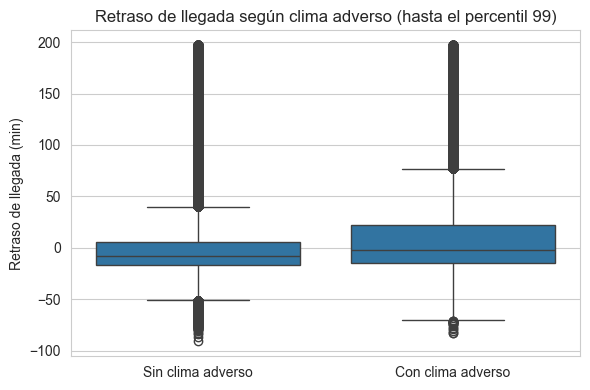

In [17]:
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")

# 1. Retraso según clima adverso (recortado al percentil 99 por la cola extrema)
limite = normal["ArrDelay"].quantile(0.99)
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=normal[normal["ArrDelay"] <= limite], x="clima_adverso", y="ArrDelay", ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Sin clima adverso", "Con clima adverso"])
ax.set_xlabel("")
ax.set_ylabel("Retraso de llegada (min)")
ax.set_title("Retraso de llegada según clima adverso (hasta el percentil 99)")
plt.tight_layout()
plt.savefig("../reports/figures/01_retraso_clima_adverso.png", dpi=150, bbox_inches="tight")
plt.show()


El diagrama de cajas confirma lo visto en la sección 3: con clima adverso la mediana de retraso sube y la caja se desplaza hacia valores positivos, frente a una mediana negativa (llegadas adelantadas) sin él. La dispersión también es mayor con clima adverso, coherente con una mayor variabilidad operativa en esas condiciones.

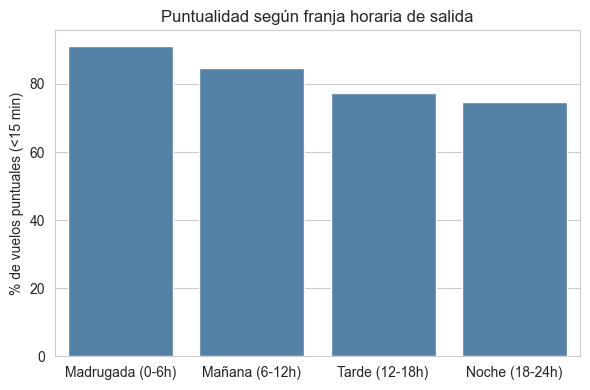

In [18]:
# 2. % puntualidad por franja horaria
orden_franja = ["Madrugada (0-6h)", "Mañana (6-12h)", "Tarde (12-18h)", "Noche (18-24h)"]
pct = normal.groupby("franja_hora", observed=True)["ArrDel15"].apply(lambda s: (s == 0).mean() * 100).reindex(orden_franja)
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=pct.index, y=pct.values, ax=ax, color="steelblue")
ax.set_ylabel("% de vuelos puntuales (<15 min)")
ax.set_xlabel("")
ax.set_title("Puntualidad según franja horaria de salida")
plt.tight_layout()
plt.savefig("../reports/figures/02_puntualidad_franja.png", dpi=150, bbox_inches="tight")
plt.show()



El gráfico de barras muestra el patrón más consistente de todo el análisis descriptivo: la puntualidad decrece de forma monótona a lo largo del día, de 91,2 % en madrugada a 74,8 % en noche. Es visualmente el efecto más claro y regular de las variables no climáticas estudiadas.

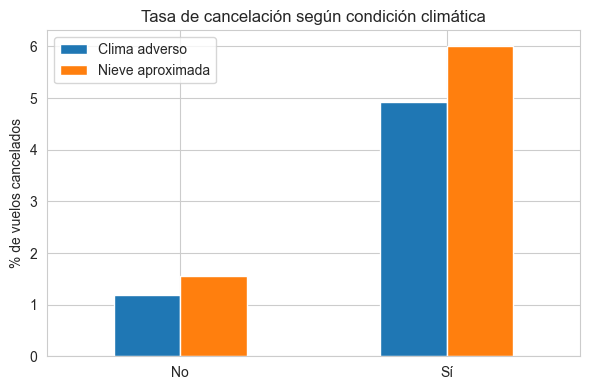

In [19]:
# 3. Tasa de cancelación por clima adverso y nieve aproximada
tasas = pd.DataFrame({
    "Clima adverso": df.groupby("clima_adverso", observed=True)["estado"].apply(lambda s: (s == "cancelado").mean() * 100),
    "Nieve aproximada": df.groupby("nieve_aprox", observed=True)["estado"].apply(lambda s: (s == "cancelado").mean() * 100)
})
tasas.index = ["No", "Sí"]
fig, ax = plt.subplots(figsize=(6, 4))
tasas.plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("% de vuelos cancelados")
ax.set_xlabel("")
ax.set_title("Tasa de cancelación según condición climática")
plt.tight_layout()
plt.savefig("../reports/figures/03_cancelacion_clima.png", dpi=150, bbox_inches="tight")
plt.show()



Las barras hacen evidente la magnitud del efecto: la tasa de cancelación se multiplica por algo más de 4 con clima adverso (1,19 % → 4,93 %) y por casi 4 con nieve aproximada (1,56 % → 6,01 %). El efecto de la nieve es el mayor de los dos, en línea con el resto del análisis.

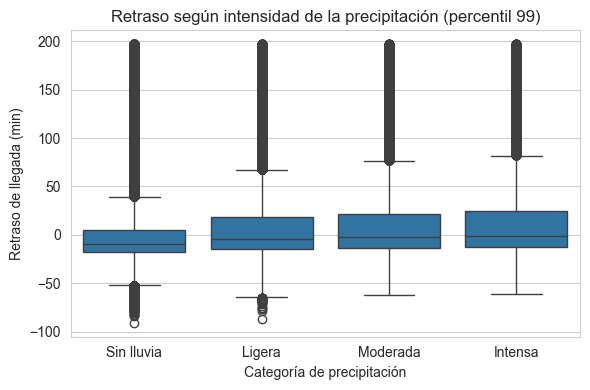

Figuras guardadas en reports/figures/:
['01_retraso_clima_adverso.png', '02_puntualidad_franja.png', '03_cancelacion_clima.png', '04_retraso_precipitacion.png']


In [16]:
# 4. Retraso según categoría de precipitación
orden_precip = ["Sin lluvia", "Ligera", "Moderada", "Intensa"]
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=normal[normal["ArrDelay"] <= limite], x="precip_cat", y="ArrDelay",
           order=orden_precip, ax=ax)
ax.set_xlabel("Categoría de precipitación")
ax.set_ylabel("Retraso de llegada (min)")
ax.set_title("Retraso según intensidad de la precipitación (percentil 99)")
plt.tight_layout()
plt.savefig("../reports/figures/04_retraso_precipitacion.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figuras guardadas en reports/figures/:")
print(sorted(p.name for p in Path("../reports/figures").glob("*.png")))

El diagrama de cajas muestra un gradiente claro entre categorías: la mediana pasa de -8 min sin lluvia a 0 min con precipitación intensa, con cajas cada vez más desplazadas hacia el retraso a medida que aumenta la intensidad. Con esto se cierran las visualizaciones del análisis descriptivo; el notebook 04_estadistica.ipynb cuantifica la significación de estos patrones.